In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [18]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    label: str

In [19]:
def calculate_bmi(state: BMIState) -> BMIState:
    state['bmi'] = state['weight'] / (state['height'] ** 2)
    return state

In [20]:
def label_bmi(state: BMIState) -> BMIState:
    if state['bmi'] < 18.5:
        state['label'] = 'Underweight'
    elif 18.5 <= state['bmi'] < 24.9:
        state['label'] = 'Normal weight'
    elif 25 <= state['bmi'] < 29.9:
        state['label'] = 'Overweight'
    else:
        state['label'] = 'Obesity'
    return state

In [21]:
# create Graph
graph = StateGraph(BMIState)

# create nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("label_bmi", label_bmi)

# create edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi", END)

# compile graph
workflow = graph.compile()

In [25]:
# run workflow
initial_state: BMIState = {"weight": 90, "height": 1.75}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight': 90, 'height': 1.75, 'bmi': 29.387755102040817, 'label': 'Overweight'}


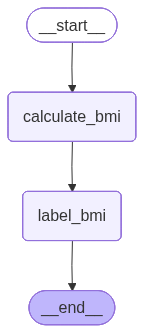

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())